In [1]:
from sklearn.datasets import load_iris
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
from sklearn.preprocessing import MinMaxScaler
from sklearn.neighbors import KNeighborsClassifier 

C:\Users\delta\anaconda3\Lib\site-packages\scipy\__init__.py:132: UserWarning: A NumPy version >=1.21.6 and <1.28.0 is required for this version of SciPy (detected version 2.1.3)
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"

A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.1.3 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "C:\Users\delta\anaconda3\Lib\site-packages\ipykernel_launcher.py", line 17, in <module>
    app.launch_new_instance()
  File "C:\Users\delta\anaconda3\Lib\site-pa

AttributeError: _ARRAY_API not found

ImportError: numpy.core.multiarray failed to import

#### 1. Постройте последний график методических указаний в исходном пространстве признаков.

In [203]:
iris = load_iris() 
features = iris.data

data = pd.DataFrame(features, columns = iris.feature_names)

In [204]:
X = data.iloc[:, [0, 2]]
y = iris.target
X.shape, y.shape

((150, 2), (150,))

In [205]:
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

In [206]:
knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(X_scaled, y)

KNeighborsClassifier(n_neighbors=3)

In [207]:
observation_new = [[5.5, 5]]
observation_new_scaled = scaler.transform(observation_new)
distances, indices = knn.kneighbors(observation_new_scaled)
distances, indices

C:\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


(array([[0.03254042, 0.05555556, 0.08503951]]),
 array([[121, 113, 101]], dtype=int64))

In [208]:
X.iloc[indices[0]]

,sepal length (cm),petal length (cm)
121,5.6,4.9
113,5.7,5.0
101,5.8,5.1


C:\Users\Ксения\AppData\Local\Temp\ipykernel_28360\499093485.py:6: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  plt.scatter(X.iloc[indices[0]].iloc[i][0], X.iloc[indices[0]].iloc[i][1], marker='+', color='g')


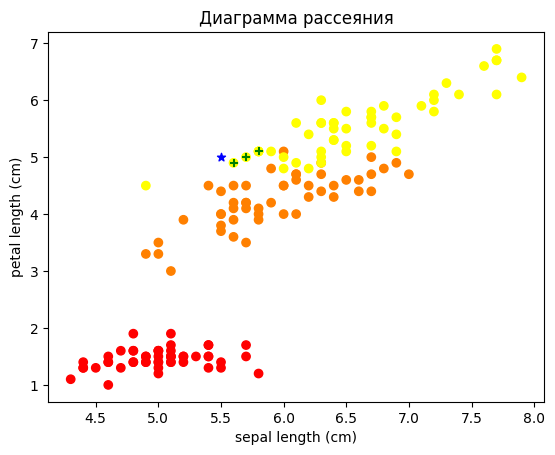

In [209]:
plt.scatter(X.iloc[:, 0], X.iloc[:, 1], c=y, cmap='autumn')

plt.scatter(observation_new[0][0], observation_new[0][1], marker='*', color='b')

for i in range(len(indices[0])):
    plt.scatter(X.iloc[indices[0]].iloc[i][0], X.iloc[indices[0]].iloc[i][1], marker='+', color='g')

plt.xlabel('sepal length (cm)')
plt.ylabel('petal length (cm)')
plt.title("Диаграмма рассеяния")
plt.show()

#### 2. Попробуйте обучить модель с другим значением k. Визуализируйте области классификации и сравните эффективности модели.

In [210]:
knn1 = KNeighborsClassifier(n_neighbors=1)
knn1.fit(X_scaled, y)
y_pred1 = knn1.predict(X_scaled)

In [211]:
knn3 = KNeighborsClassifier(n_neighbors=3)
knn3.fit(X_scaled, y)
y_pred3 = knn3.predict(X_scaled)

In [212]:
knn25 = KNeighborsClassifier(n_neighbors=25)
knn25.fit(X_scaled, y)
y_pred25 = knn25.predict(X_scaled)

In [213]:
def visualize(model):
    X0 = np.linspace(X.iloc[:, 0].min()-1,X.iloc[:, 0].max()+1, X.shape[0])
    X1 = np.linspace(X.iloc[:, 1].min()-1,X.iloc[:, 1].max()+1, X.shape[0])

    X0_grid, X1_grid = np.meshgrid(X0, X1)

    XX = np.array([X0_grid.ravel(), X1_grid.ravel()]).T

    XX_scaled = scaler.transform(XX)
    Z = model.predict(XX_scaled).reshape(X0_grid.shape)

    plt.scatter(X.iloc[:, 0], X.iloc[:, 1], c=y, cmap='autumn')
    plt.contourf(X0_grid, X1_grid, Z, cmap='autumn', alpha=0.2)

    plt.xlabel('sepal length (cm)')
    plt.ylabel('petal length (cm)')
    plt.title(f"Диаграмма рассеяния с областями классификации knn = {model.n_neighbors} ")
    plt.show()

C:\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


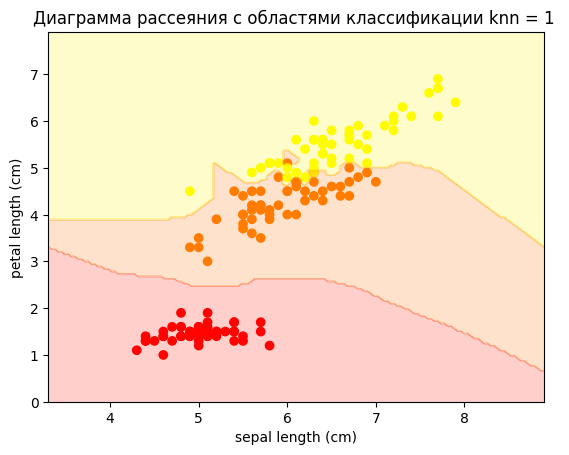

C:\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


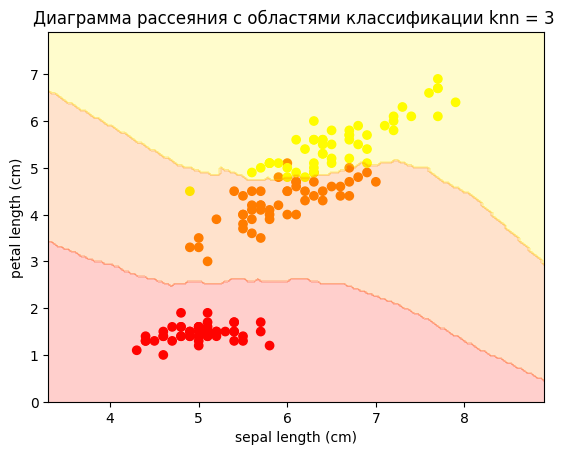

C:\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


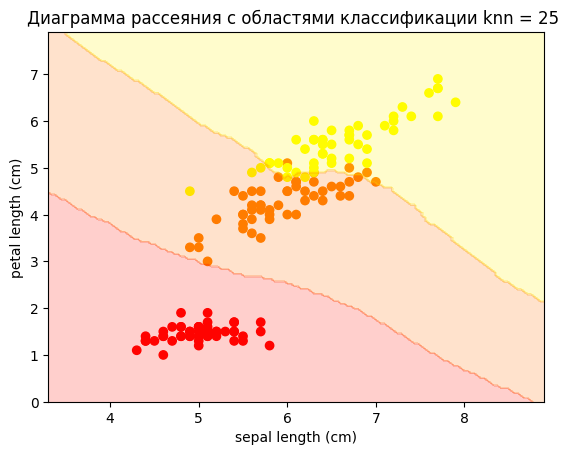

In [214]:
for k in [knn1, knn3, knn25]:
    visualize(k)

In [216]:
print(classification_report(y, y_pred1))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        50
           1       0.98      1.00      0.99        50
           2       1.00      0.98      0.99        50

    accuracy                           0.99       150
   macro avg       0.99      0.99      0.99       150
weighted avg       0.99      0.99      0.99       150



In [217]:
print(classification_report(y, y_pred3))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        50
           1       0.94      0.94      0.94        50
           2       0.94      0.94      0.94        50

    accuracy                           0.96       150
   macro avg       0.96      0.96      0.96       150
weighted avg       0.96      0.96      0.96       150



In [218]:
print(classification_report(y, y_pred25))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        50
           1       0.90      0.90      0.90        50
           2       0.90      0.90      0.90        50

    accuracy                           0.93       150
   macro avg       0.93      0.93      0.93       150
weighted avg       0.93      0.93      0.93       150



#### 3. Подвигайте новое наблюдение в последнем пункте методических указаний. Сдвиньте его за пределы области определения выборки. Как меняется нормализованное значение?

In [219]:
X.max(), X.min()

(sepal length (cm)    7.9
 petal length (cm)    6.9
 dtype: float64,
 sepal length (cm)    4.3
 petal length (cm)    1.0
 dtype: float64)

In [220]:
# значения за пределами диапазона
false_obs1 = [[8.5, 0.5]]  
false_obs2 = [[3.3, 7.5]] 

false_obs_scaled1 = scaler.transform(false_obs1)
false_obs_scaled2 = scaler.transform(false_obs2)
print(false_obs_scaled1, false_obs_scaled2)

[[ 1.16666667 -0.08474576]] [[-0.27777778  1.10169492]]


C:\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(
C:\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


#### 4. Поэкспериментируйте с разными метриками расстояния. Визуализируйте ближайших соседей нового объекта при разных метриках расстояния.

In [221]:
new_object = [[6, 3.5]]
new_object_scaled = scaler.transform(new_object)

C:\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


In [222]:
def plot_metrics(indices, object_scaled):
    plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=y, cmap='autumn')

    plt.scatter(object_scaled[0][0], object_scaled[0][1], marker='*', color='b')

    for i in range(len(indices[0])):
        plt.scatter(X_scaled[indices[0]][i][0], X_scaled[indices[0]][i][1], marker='+', color='g')

    plt.xlabel('sepal length (cm)')
    plt.ylabel('petal length (cm)')
    plt.show()

In [223]:
model_euclidean = KNeighborsClassifier(n_neighbors=3, metric='euclidean')
model_euclidean.fit(X_scaled, y)
neighbors_euclidean = model_euclidean.kneighbors(new_object_scaled, return_distance=False)

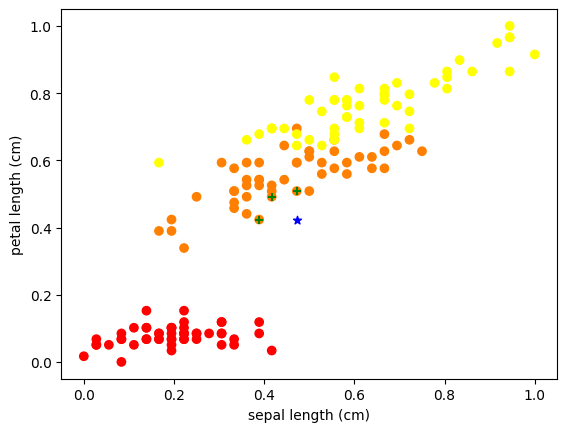

In [224]:
plot_metrics(neighbors_euclidean, new_object_scaled)

In [225]:
model_manhattan = KNeighborsClassifier(n_neighbors=3, metric='manhattan')
model_manhattan.fit(X_scaled, y)
neighbors_manhattan = model_manhattan.kneighbors(new_object_scaled, return_distance=False)

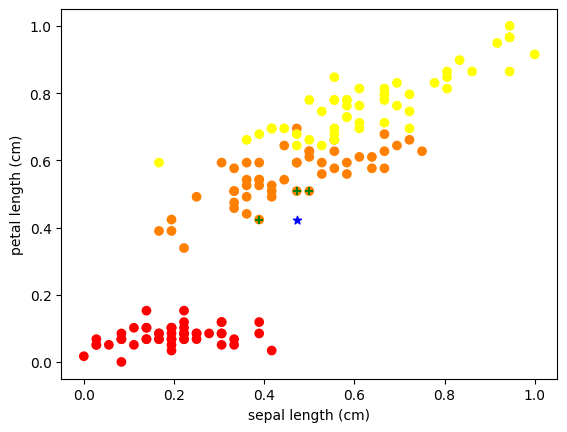

In [226]:
plot_metrics(neighbors_manhattan, new_object_scaled)

In [227]:
model_chebyshev = KNeighborsClassifier(n_neighbors=3, metric='chebyshev')
model_chebyshev.fit(X_scaled, y)
neighbors_chebyshev = model_chebyshev.kneighbors(new_object_scaled, return_distance=False)

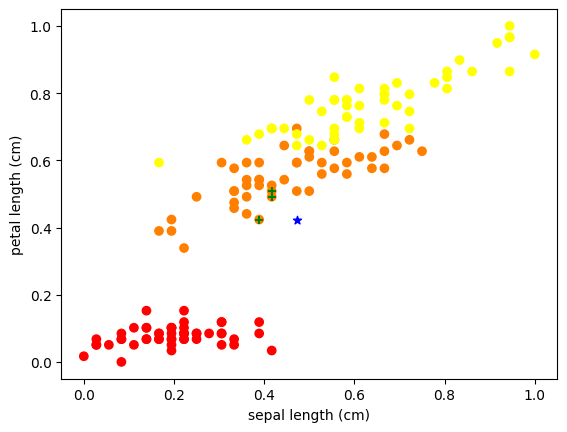

In [228]:
plot_metrics(neighbors_chebyshev, new_object_scaled)

#### 5. Обучите модель на полном датасете. Сравните ее эффективность с описанной в методических указаниях. Попробуйте разные значения k.

In [229]:
X = data
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

In [230]:
knn1 = KNeighborsClassifier(n_neighbors=1)
knn1.fit(X_scaled, y)
y_pred1 = knn1.predict(X_scaled)

In [231]:
knn3 = KNeighborsClassifier(n_neighbors=3)
knn3.fit(X_scaled, y)
y_pred3 = knn3.predict(X_scaled)

In [232]:
knn25 = KNeighborsClassifier(n_neighbors=25)
knn25.fit(X_scaled, y)
y_pred25 = knn25.predict(X_scaled)

In [233]:
print(classification_report(y, y_pred1))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        50
           1       1.00      1.00      1.00        50
           2       1.00      1.00      1.00        50

    accuracy                           1.00       150
   macro avg       1.00      1.00      1.00       150
weighted avg       1.00      1.00      1.00       150



In [234]:
print(classification_report(y, y_pred3))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        50
           1       0.94      0.96      0.95        50
           2       0.96      0.94      0.95        50

    accuracy                           0.97       150
   macro avg       0.97      0.97      0.97       150
weighted avg       0.97      0.97      0.97       150



In [235]:
print(classification_report(y, y_pred25))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        50
           1       0.92      0.94      0.93        50
           2       0.94      0.92      0.93        50

    accuracy                           0.95       150
   macro avg       0.95      0.95      0.95       150
weighted avg       0.95      0.95      0.95       150



#### 6. Попробуйте в модели на полном датасете взвешенный алгоритм (аргумент weights объекта KNeighborsClassifier). Сравние его точность с равномерным вариантом.

In [236]:
knn1_weight = KNeighborsClassifier(n_neighbors=1, weights='distance')
knn1_weight.fit(X_scaled, y)
y_pred1_weight = knn1_weight.predict(X_scaled)

In [237]:
print(classification_report(y, y_pred1_weight))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        50
           1       1.00      1.00      1.00        50
           2       1.00      1.00      1.00        50

    accuracy                           1.00       150
   macro avg       1.00      1.00      1.00       150
weighted avg       1.00      1.00      1.00       150



In [239]:
knn3_weight = KNeighborsClassifier(n_neighbors=3, weights='distance')
knn3_weight.fit(X_scaled, y)
y_pred3_weight = knn3_weight.predict(X_scaled)

In [240]:
print(classification_report(y, y_pred3_weight))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        50
           1       1.00      1.00      1.00        50
           2       1.00      1.00      1.00        50

    accuracy                           1.00       150
   macro avg       1.00      1.00      1.00       150
weighted avg       1.00      1.00      1.00       150



In [242]:
knn25_weight = KNeighborsClassifier(n_neighbors=25, weights='distance')
knn25_weight.fit(X_scaled, y)
y_pred25_weight = knn25_weight.predict(X_scaled)

In [243]:
print(classification_report(y, y_pred25_weight))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        50
           1       1.00      1.00      1.00        50
           2       1.00      1.00      1.00        50

    accuracy                           1.00       150
   macro avg       1.00      1.00      1.00       150
weighted avg       1.00      1.00      1.00       150



#### 7. Постройте график точности (accuracy) модели в зависимости от значения k. Сделайте вывод.

In [245]:
X = pd.DataFrame(iris.data, columns=iris.feature_names)
y = iris.target

In [246]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [247]:
k_values = range(1, 21)
accuracies = []

for k in k_values:
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(X_scaled, y)
    y_pred = model.predict(X_scaled)
    accuracies.append(accuracy_score(y, y_pred))

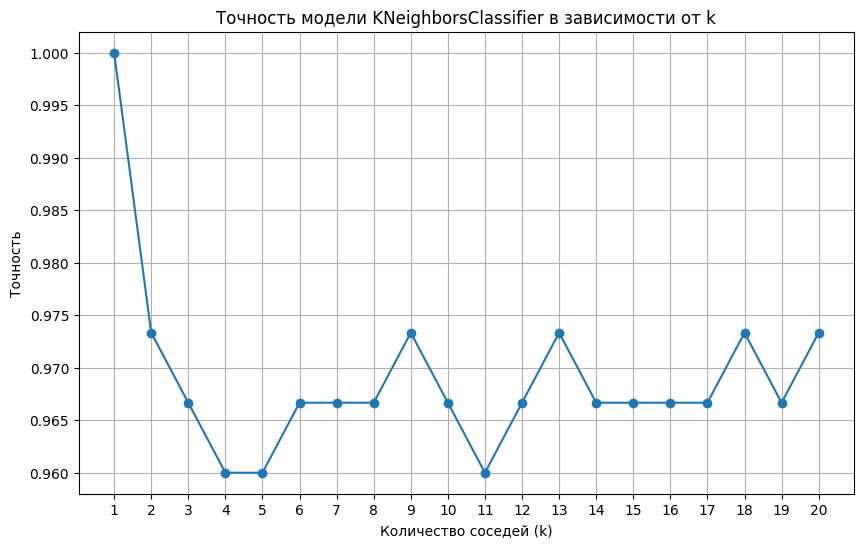

In [248]:
plt.figure(figsize=(10, 6))
plt.plot(k_values, accuracies, marker='o')
plt.title('Точность модели KNeighborsClassifier в зависимости от k')
plt.xlabel('Количество соседей (k)')
plt.ylabel('Точность')
plt.xticks(k_values)
plt.grid()
plt.show()

#### 8. Выберите датасет и постройте регрессию при помощи метода ближайших соседей.

In [249]:
from sklearn.datasets import load_diabetes
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error

In [250]:
diabetes = load_diabetes()
X = pd.DataFrame(diabetes.data, columns=diabetes.feature_names)
y = diabetes.target
X.shape, y.shape

((442, 10), (442,))

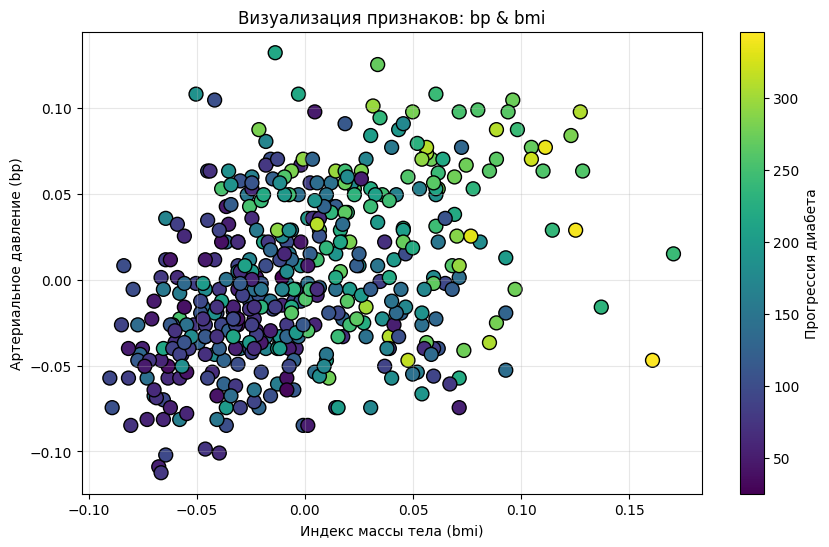

In [251]:
plt.figure(figsize=(10, 6))
plt.scatter(plot_X.iloc[:, 0], plot_X.iloc[:, 1], c=y, edgecolor='k', s=100)
plt.colorbar(label='Прогрессия диабета')
plt.title('Визуализация признаков: bp & bmi')
plt.xlabel('Индекс массы тела (bmi)')
plt.ylabel('Артериальное давление (bp)')
plt.grid(alpha=0.3)
plt.show()

In [252]:
d_scaler = MinMaxScaler()
X_scaled = d_scaler.fit_transform(X)

In [253]:
regr_knn = KNeighborsRegressor(n_neighbors=7)
regr_knn.fit(X_scaled, y)
y_pred_regr = regr_knn.predict(X_scaled)

Text(0.5, 1.0, 'Фактические vs Предсказанные значения')

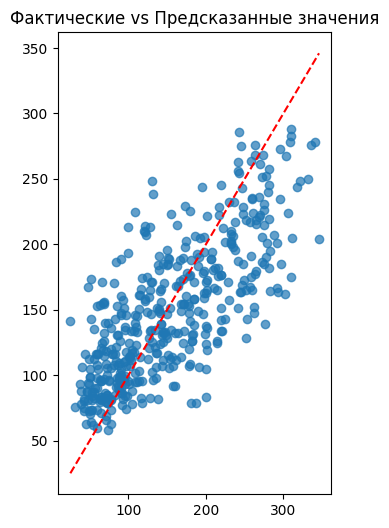

In [254]:
plt.figure(figsize=(12, 6))
plt.subplot(1, 3, 1)
plt.scatter(y, y_pred_regr, alpha=0.7)
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--')
plt.title('Фактические vs Предсказанные значения')

In [255]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [256]:
mse = mean_squared_error(y, y_pred_regr)
mae = mean_absolute_error(y, y_pred_regr)
r2 = r2_score(y, y_pred_regr)

print(f'Среднеквадратичная ошибка (MSE): {mse:.2f}')
print(f'Средняя абсолютная ошибка (MAE): {mae:.2f}')
print(f'Коэффициент детерминации (R²): {r2:.2f}')

Среднеквадратичная ошибка (MSE): 2615.03
Средняя абсолютная ошибка (MAE): 40.51
Коэффициент детерминации (R²): 0.56
